# Task

Create a convolutional neural network to process the MNIST dataset.

Compare it with a neural network with fully connected layers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and display data

In [2]:
from keras.datasets import mnist
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

2025-12-11 14:16:25.470548: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-11 14:16:25.730052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 14:16:36.225047: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Reminder that values take on shades of grey 0 - 255
* 0 is black
* 255 is white

In [3]:
img = X_train[0]
print (f"min:{np.amin(X_train[0])} max:{np.amax(X_train[0])}")

min:0 max:255


In [4]:
def show_images (images, labels, rows=6, cols=10):
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    for idx in range (0, rows * cols):
        ridx=idx // cols
        cidx=idx % cols
        ax= axes[ridx, cidx]
        ax.axis("off")
        ax.imshow(images[idx], cmap="gray_r")
        ax.set_title(f"{labels[idx]}")
    plt.show()    

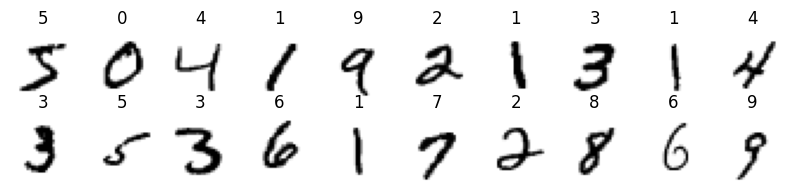

In [5]:
show_images(X_train, Y_train, 2, 10)

In [6]:
# X_train[0] number [0] row [0] collumn 
print("Rows number (size of column):", str(len(X_train[0])))
print("Column number (size of Rows):", str(len(X_train[0][0])))

Rows number (size of column): 28
Column number (size of Rows): 28


# Data preparation

Standardization of values from range 0 - 255 to range 0 - 1

In [7]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

Binary encoding

In [8]:
from keras.utils import to_categorical 
Y_train = to_categorical(Y_train, num_classes=10)
Y_test = to_categorical(Y_test, num_classes=10)
Y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

# Neural network

In [9]:
import keras
from keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from keras.models import Sequential

In [10]:
# Creating and learning the model

In [11]:
model = Sequential()

In [12]:
model.add(Input(shape=(28,28,1))) # 28 * 28 , 1 chanel

In [13]:
model.add(Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'))
# max number of filters 512 more does not have sense here
# 8 directions of line, 8 cureves prediction of masks

2025-12-11 14:16:43.872404: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [15]:
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))

In [16]:
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))

In [17]:
model.add(Flatten())
model.add(Dense(128, activation='relu'))

In [18]:
model.add(Dense(10, activation='softmax')) 

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,794 (745.29 KB)

 Trainable params: 190,794 (745.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam', loss="categorical_crossentropy", metrics=['accuracy'])
early_stop = keras.callbacks.EarlyStopping(monitor='accuracy', patience=30)
history = model.fit(X_train, Y_train, batch_size=64, epochs=10, callbacks=[early_stop])


Epoch 1/10


2025-12-11 14:16:46.469233: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


938/938 ━━━━━━━━━━━━━━━━━━━━ 266s 268ms/step - accuracy: 0.8356 - loss: 0.4798
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 242s 247ms/step - accuracy: 0.9806 - loss: 0.0605
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 174s 185ms/step - accuracy: 0.9878 - loss: 0.0401
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 164s 175ms/step - accuracy: 0.9896 - loss: 0.0342
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 164s 175ms/step - accuracy: 0.9909 - loss: 0.0303
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 157s 168ms/step - accuracy: 0.9924 - loss: 0.0247
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 150s 160ms/step - accuracy: 0.9940 - loss: 0.0202
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 131s 139ms/step - accuracy: 0.9940 - loss: 0.0177
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 126s 134ms/step - accuracy: 0.9949 - loss: 0.0169
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 159s 170ms/step - accuracy: 0.9949 - loss: 0.0158


In [33]:
model.save('.\classification_model_mnist.keras')

# History of learning model
- Show learning curve
- Show model accuracy curve
- Describe the shapes

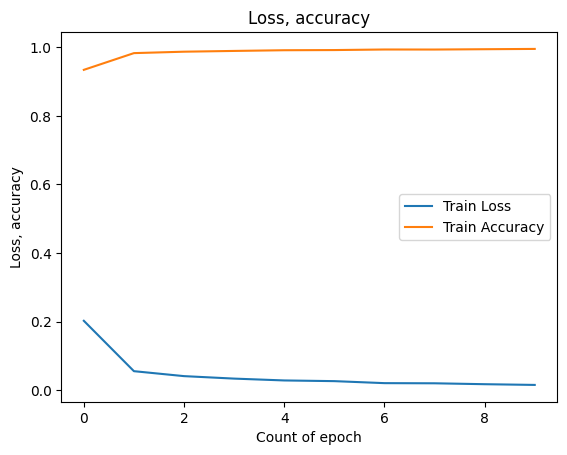

In [34]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Count of epoch')
plt.show()

# Model Verification
- R2 score
- Accuracy of the model as a whole
- Accuracy across classes
- Change matrix
- Examples of misclassification

In [35]:
model = keras.models.load_model('.\classification_model_mnist.keras')

In [36]:
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix, accuracy_score


In [37]:
Y_pred = model.predict(X_test)
Y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


array([1.1478978e-14, 9.2791851e-11, 2.1829871e-09, 6.0225275e-12,
       4.7135164e-11, 8.2528089e-15, 7.4742047e-18, 9.9999994e-01,
       2.7782862e-13, 7.3264804e-11], dtype=float32)

In [38]:
Y_pred_best_answer = np.argmax(Y_pred, axis=-1)
Y_pred_best_answer[0]

np.int64(7)

In [39]:
Y_test_best_answer = np.argmax(Y_test, axis=-1)
Y_test_best_answer[0]

np.int64(7)

In [40]:

r2 = r2_score(Y_test_best_answer, Y_pred_best_answer)
print('R2 score: {}'.format(r2))

R2 score: 0.9849496668440603


<Axes: >

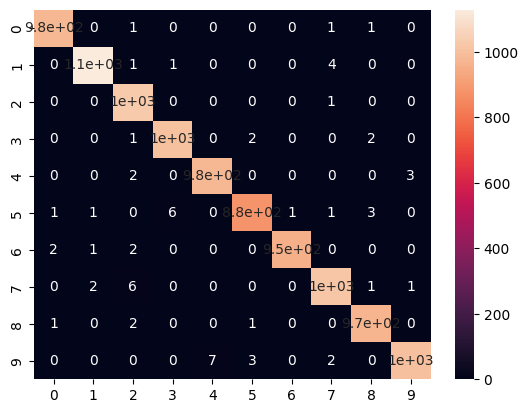

In [41]:
cf_matrix=confusion_matrix(Y_test_best_answer, Y_pred_best_answer)
sns.heatmap(cf_matrix, annot=True)

In [45]:
class_correct, class_count = [0]*10, [0]*10

for i in range(Y_test.shape[0]):    
    if (Y_test_best_answer[i] == Y_pred_best_answer[i]):
        class_correct[Y_test_best_answer[i]] +=1
    class_count[Y_test_best_answer[i]] += 1
    
for i in range(10):
    #print (f"Accuracy for {className[i]}: {class_correct[i]/class_count[i]:.2%}") 
    print (f"Accuracy for {str(i)}: {class_correct[i]/class_count[i]:.2%}") 

Accuracy for 0: 99.69%
Accuracy for 1: 99.47%
Accuracy for 2: 99.90%
Accuracy for 3: 99.50%
Accuracy for 4: 99.49%
Accuracy for 5: 98.54%
Accuracy for 6: 99.48%
Accuracy for 7: 99.03%
Accuracy for 8: 99.59%
Accuracy for 9: 98.81%


In [47]:
def show_wrong_predictions(X_test, Y_test, Y_pred, rows=5, cols=5):        
    idx = 0
    max_examples = rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows), constrained_layout=True)    
    for i in range(Y_test.shape[0]):    
        if (Y_test[i] != Y_pred[i]):                                    
            ridx=idx // cols
            cidx=idx % cols            
            ax = axes[ridx, cidx]
            ax.axis("off")
            ax.imshow(X_test[i].reshape(28,28,1), cmap="gray_r")
            #ax.set_title(f"{class_names[Y_test[i]]} != {class_names[Y_pred[i]]}")
            ax.set_title(f"{str(Y_test[i])} != {str(Y_pred[i])}")
            idx +=1
            if (idx == max_examples):
                break

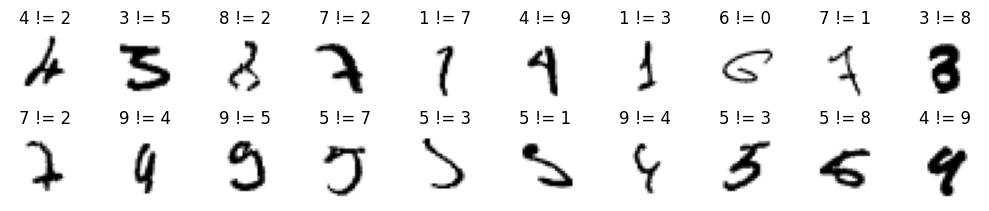

In [44]:
show_wrong_predictions(X_test, Y_test_best_answer, Y_pred_best_answer, 2, 10)


# Model Comparison
- Which model is more accurate
- How about the learning time
- How about the time of inference